# 시나리오

- wyz위젯 컴퍼니(가상의 회사)의 위젯 판매량을 예측

- 미래의 판매량을 예측할 수 있다면 위젯 생산을 관리하여 효율적인 경영 가능

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("./data/csv/widget_sales.csv")
df.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


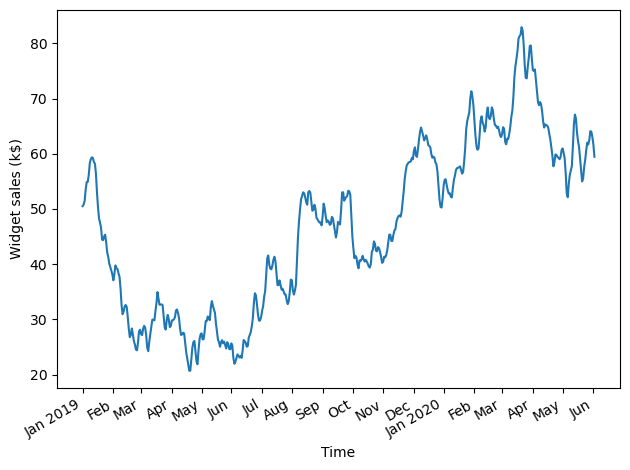

In [6]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 2019년부터 500일 동안의 위젯 판매량 그래프

- 최고점과 최저점이 반복되는 장기적인 추세 확인 가능

- 시간의 흐름에 따른 추세가 있으므로 시계열이 정상적 프로세스는 아니며, 뚜렷한 주기적 패턴은 확인되지 않음

- 프로세스를 분석한 후 향후 50일 동안의 위젯 판매량 예측 목표

# 이동평균프로세스(moving average process) 정의

- 이동평균프로세스 또는 이동평균 모델(MA)은 현재 시점의 값이 현재와 과거의 오차항들의 선형 결합으로 결정된다고 정의

- 또한 오차가 백색소음과 마찬가지로 상호 독립적이며 정규분포한다고 가정

- 이동평균 모델은 MA(q)로 표시하고, 여기서 q는 차수임

- 수식
    - $$y_t = \mu + \epsilon_t + \theta_1\epsilon_{t-1} + \cdots + \theta_q\epsilon_{t-q}$$
        - $y_t$ : 현재 시점의 값
        - $\mu$ : 수열의 평균
        - $\epsilon_t$ : 현재 오차항
        - $\epsilon_{t-q}$ : 과거 오차항
 
- 이동평균 모델의 차수 q는 현재의 값에 영향을 미치는 과거 오차항의 개수를 결정

- q가 클수록 더 많은 과거 오차 항이 현재의 값에 영향을 미침
    - 따라서 이동평균프로세스의 차수를 적절히 결정해야만 이동평균프로세스에 적합한 모델을 구축할 수 있음

## 이동평균프로세스의 차수 식별

<img src = "./image/MA차수_식별.png" width = 600 height = 600>

1. 데이터 수집

2. 정상성 테스트

3. 수열이 정상성을 만족하지 않으면 수열이 정상성을 만족할 때까지 차분과 같은 변환을 적용

4. ACF를 시각화하여 유의한 자기상관계수를 찾기
    - 확률보행이라면 지연 0 이후로 유의한 계수를 찾을 수 없음
  
5. 유의한 계수들을 찾았다면, 지연 q 이후 갑자기 계수들이 유의하지 않게 되는지 확인
    - 유의하지 않게 된다면 차수 q의 이동평균프로세스임
    - 지연 q 이후에도 유의하다면 시계열 기반 프로세스를 식별하기 위한 다음 단계로 넘어가야 함

### 예제 데이터에 적용

- 2019년 1월 1일부터 500일간의 판매량 데이터

- 위의 절차에 따라 이동평균 프로세스의 차수를 결정

#### 정상성 테스트

- 그래프를 확인하면 직관적으로 비정상적 수열임을 확인할 수 있음

- 정확하게 확인하기 위해서는 ADF 테스트로 확인
    - 귀무가설 : 단위근이 존재한다(비정상 시계열이다)
    - 대립가설 : 단위근이 존재하지 않는다(정상 시계열이다)

In [7]:
ADF_result = adfuller(df["widget_sales"])

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -1.5121662069358992
p-value: 0.5274845352272632


- 비정상 시계열이므로 정상 시계열로 변환해야함

In [8]:
# 1차 차분
widget_sales_diff = np.diff(df["widget_sales"], n = 1)

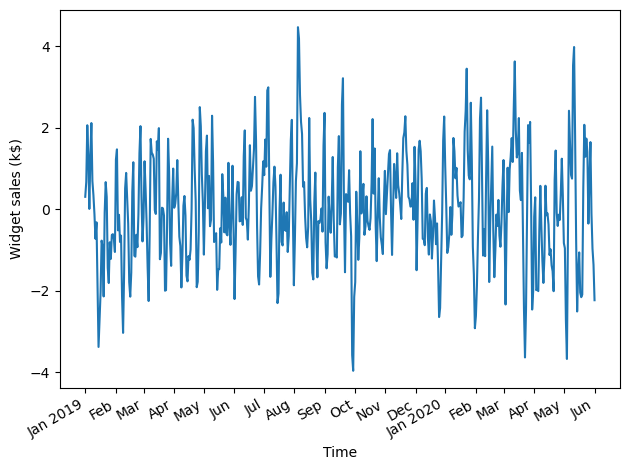

In [9]:
# 정상화 되었는지 확인
fig, ax = plt.subplots()

ax.plot(widget_sales_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 전체 기간에서 값이 0 근처에 고정되어 있으므로 추세 구성요소가 제거되고 정상화 된 것으로 보임

In [10]:
# 차분된 시계열 ADF 테스트
ADF_result = adfuller(widget_sales_diff)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -10.576657780341955
p-value: 7.076922818587346e-19


- 시계열이 정상성을 만족함

#### ACF(자기상관함수) 시각화

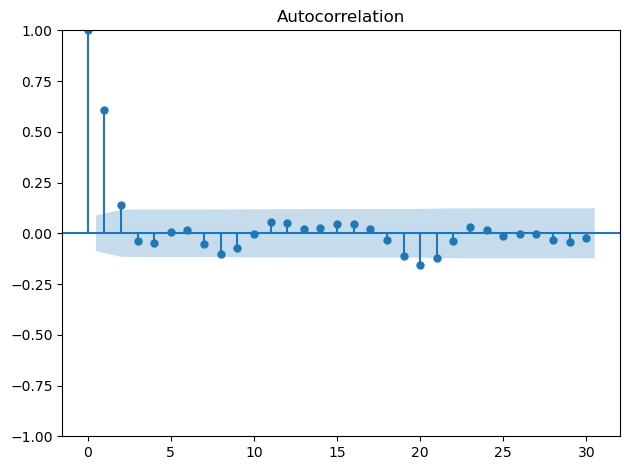

In [11]:
plot_acf(widget_sales_diff, lags = 30)

plt.tight_layout()

plt.show()

- 지연 2까지는 유의한 계수가 있다가 갑자기 유의하지 않게 되어 도식상의 음영 영역에서 벗어나지 않음
    - 차수 2의 정상적 이동평균 프로세스임
    - 즉, 2차 이동평균 모델 또는 MA(2) 모델을 사용하여 정상적 시계열 예측 수행 가능

- ACF 그래프로 지연 q까지 유의한 자기상관계수를 확인하고, 해당 지연 이후에는 모든 계수가 유의하지 않다는 점을 확인
    - 특정 지연 이후 모든 계수가 유의하지 않다면 이동평균 프로세스가 있다고 결론 내릴 수 있음

# 이동평균프로세스 예측

- 이동평균프로세스의 차수 q를 식별하고 나면, 모델을 훈련하고 예측을 시작할 수 있음
    - 이번 사례에서는 위젯 판매량을 1차 차분한 값이 차수가 2인 이동평균 프로세스(MA(2)) 라는 것을 식별함
 
- 이동평균모델은 수열이 정상성을 만족하는 것을 가정
    - 정상적 시계열에 대해서만 예측 수행 가능
 
- 따라서 위젯 판매량을 차분한 값으로 훈련하고 테스트 수행

- 단순한 예측 기법을 시도해보고 차수가 2인 이동평균 모델과 비교
    - 차분한 데이터로 예측값을 구할 것이므로 예측값을 역변환해야 실제값과 비교 가능
 
- 이번 예제에서는 훈련 : 테스트 비율을 9 : 1로 설정

In [12]:
# 훈련 : 테스트 데이터 분할
df_diff = pd.DataFrame({"widget_sales_diff" : widget_sales_diff})

In [13]:
df_diff.shape

(499, 1)

In [14]:
df.shape

(500, 1)

In [15]:
train = df_diff[:int(0.9 * len(df_diff))]
test = df_diff[int(0.9 * len(df_diff)):]

print(len(train))
print(len(test))

449
50


- 원본 데이터에는 500개의 요소가 포함되어 있지만, 차분된 수열은 차분 과정에서 1개 줄어듦

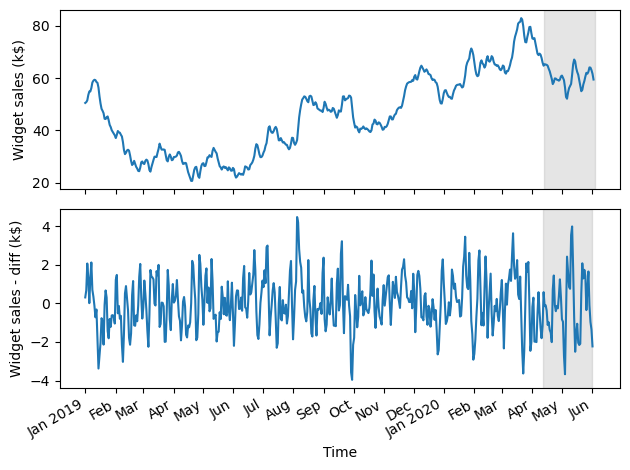

In [16]:
# 차분된 수열과 원본 수열 시각화
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, sharex = True)

ax1.plot(df["widget_sales"])
ax1.set_xlabel('Time')
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 500, color = "#808080", alpha = 0.2)

ax2.plot(df_diff["widget_sales_diff"])
ax2.set_xlabel('Time')
ax2.set_ylabel('Widget sales - diff (k$)')
ax2.axvspan(449, 498, color = "#808080", alpha = 0.2)

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- MA(q)는 앞으로의 q단계까지만 예측할 수 있음
    - MA(q)는 과거 오차 항에 선형적으로 의존
 
- q단계 이후 미래에 대해 예측하려면 반복해서 q번의 timestep씩 예측하는 함수를 개발하고 해당 예측을 테스트 집합의 관찰된 값과 비교해야 함
    - 이런 방법을 롤링 예측(rolling forecast)이라고 함
    - 예) 449개 timestep에 대해 훈련한 후, 450, 451번째 timestep을 예측. 이후 451개 timestep에 대해 훈련한 후 453번째 timestep까지 예측. 이 과정을 499번째 timestep을 예측할 때까지 반복

In [17]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str, q: int) -> list:
    '''
    df : 전체 시계열 데이터
    train_len : 훈련 집합의 크기
    horizon : 테스트 집합의 크기. 예측할 값의 개수
    window : 한 번에 예측할 timestep 개수
    method : 사용할 모델 지정
    q : MA 프로세스의 차수
    '''
    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []

        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend([mean] * window)

        return pred_mean

    elif method == "last":
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend([last_value] * window)

        return pred_last_value

    elif method == "MA":
        pred_ma = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order = (0, 0, q))
            res = model.fit(disp = False) # disp : 훈련 과정을 화면에 출력할지 여부
            predictions = res.get_prediction(0, i + window - 1) # start, end
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ma.extend(oos_pred)

        return pred_ma

In [18]:
pred_df = test.copy()

In [19]:
TRAIN_LEN = len(train) # 훈련 집합의 크기
HORIZON = len(test) # 테스트 집합의 크기(50일)
WINDOW = 2 # 예측할 timestep 수
Q = 2

In [20]:
pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "mean", Q)
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "last", Q)
pred_ma = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, "MA", Q)

In [21]:
# 예측 결과 확인
pred_df["pred_mean"] = pred_mean
pred_df["pred_last_value"] = pred_last_value
pred_df["pred_MA"] = pred_ma

pred_df.head()

,widget_sales_diff,pred_mean,pred_last_value,pred_MA
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994


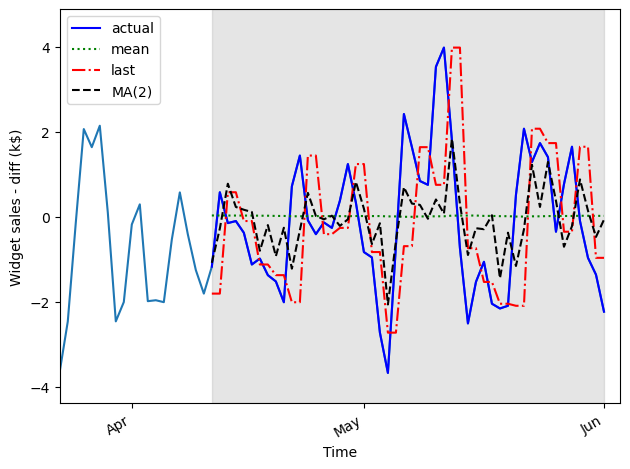

In [22]:
# 예측값과 관측값 비교 시각화
# 아직 차분된 데이터 집합이므로 예측값도 차분된 값임
fig, ax = plt.subplots()

ax.plot(df_diff["widget_sales_diff"])
ax.plot(pred_df["widget_sales_diff"], "b-", label = "actual")
ax.plot(pred_df["pred_mean"], "g:", label = "mean")
ax.plot(pred_df["pred_last_value"], "r-.", label = "last")
ax.plot(pred_df["pred_MA"], "k--", label = "MA(2)")

ax.legend()

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')
ax.axvspan(449, 498, color = "#808080", alpha = 0.2)

ax.set_xlim(430, 500)

plt.xticks(
    [439, 468, 498],
    ["Apr", "May", "Jun"]
)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 평균 예측은 거의 직선에 가까움
    - 정상 시계열에서 평균은 시간이 지나도 일정함(변화가 거의 없음)

In [23]:
# 모델 성능 측정(mse)
mse_mean = mean_squared_error(pred_df["widget_sales_diff"], pred_df["pred_mean"])
mse_last = mean_squared_error(pred_df["widget_sales_diff"], pred_df["pred_last_value"])
mse_MA = mean_squared_error(pred_df["widget_sales_diff"], pred_df["pred_MA"])

print(mse_mean, mse_last, mse_MA)

2.5606299456880537 3.2494260812249225 1.948171449798091


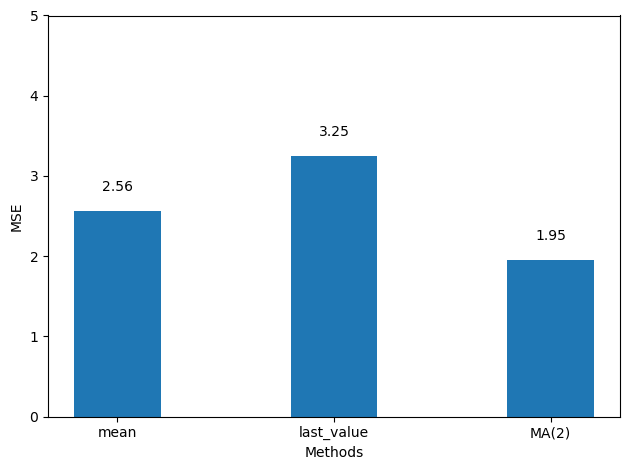

In [24]:
# 모델 성능 시각화
fig, ax = plt.subplots()

x = ["mean", "last_value", "MA(2)"]
y = [mse_mean, mse_last, mse_MA]

ax.bar(x, y, width = 0.4)

ax.set_xlabel("Methods")
ax.set_ylabel("MSE")
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.25, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

- 세 가지 기법 중 MA(2) 모델의 MSE가 가장 낮아 가장 성능이 좋은 예측 방법임

- 최고 성능 모델의 예측 결과를 역변환하여 원래의 단위로 되돌려야 함

- 차분을 역변환 하려면 차분된 값들을 누적으로 합계
    - y1 = y0 + y'1 = y0 + y1 - y0 = y1
        - y'1 : 첫 번째 차분된 값
     
    - y2 = y0 + y'1 + y'2 = y0 + y1 - y0 + y2 - y1 = y2

In [25]:
df["pred_widget_sales"] = pd.Series() # 예측값을 저장할 빈 컬럼 초기화
df["pred_widget_sales"][450:] = df["widget_sales"].iloc[450] + pred_df["pred_MA"].cumsum() # 예측값 역변환

In [26]:
df.iloc[450:455]

,widget_sales,pred_widget_sales
450,64.736005,63.657172
451,65.316972,63.383863
452,65.172070,64.165086
453,65.075506,64.400055
454,64.703173,64.56905


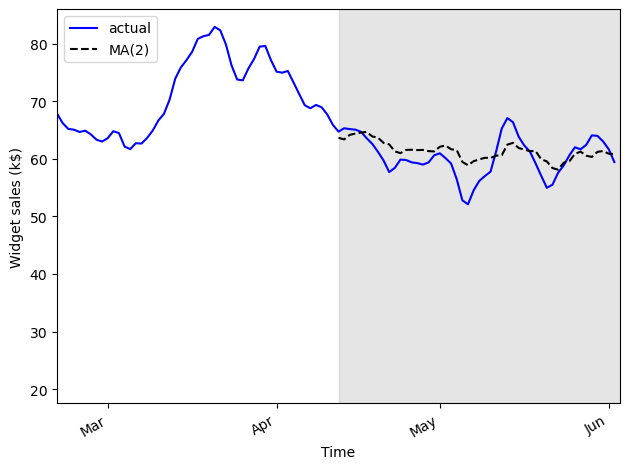

In [27]:
fig, ax = plt.subplots()

ax.plot(df["widget_sales"], "b-", label = "actual")
ax.plot(df["pred_widget_sales"], "k--", label = "MA(2)")

ax.legend()

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')
ax.axvspan(450, 500, color = "#808080", alpha = 0.2)

ax.set_xlim(400, 500)

plt.xticks(
    [409, 439, 468, 498],
    ["Mar", "Apr", "May", "Jun"]
)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

- 예측값이 관측값의 일반적인 추세는 따르지만, 최고점과 최저점은 예측하지 못함

- 실무에서는 차분된 값은 비즈니스적 의미가 없기 때문에 사용하지 않으며, 데이터의 원래 단위로 값과 오차를 사용해야 함

In [28]:
# 평균 절대 오차(mean absolute error, MAE) 측정
# 예측값과 실제 값 간 절대 차이의 평균을 반환하므로 MSE에 비해 해석이 쉬움
mae_MA_undiff = mean_absolute_error(df["widget_sales"].iloc[450:], df["pred_widget_sales"].iloc[450:])

print(mae_MA_undiff)

2.324470924593092


- 데이터의 단위가 1천 달러 이므로 평균적으로 약 2320달러 정도 오차가 발생함

# 연습문제

## 프로세스 예측 수행하기_1

1. 샘플 데이터
2. 데이터 시각화
3. 정상성 테스트 실행하고 프로세스가 정상적인지 확인
4. ACF시각화하고 지연 q 이후에 유의한 계수가 있는지 확인
5. 훈련/테스트 분할
    - 8 : 2로 분할
6. 테스트 집합에 대해 예측 수행
    - 평균, 마지막 값, MA(q) 모델을 사용하여 예측을 수행
7. 예측값 시각화
8. MSE 측정

In [29]:
# 예제 데이터 불러오기
process = np.load("./data/npy/q4-1.npy")

In [30]:
type(process)

numpy.ndarray

In [31]:
process.shape

(1000,)

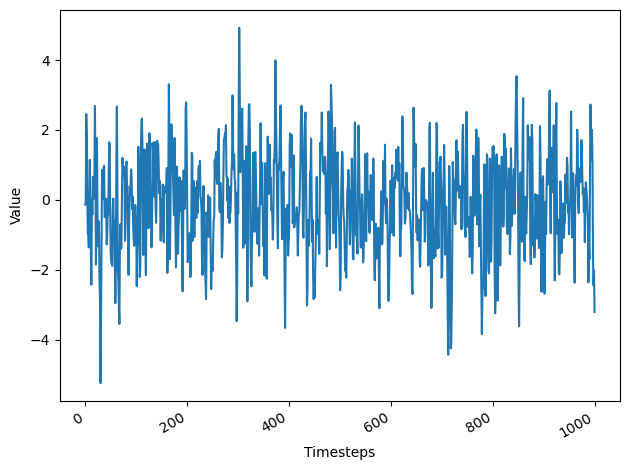

In [32]:
# 프로세스 시각화
fig, ax = plt.subplots()

ax.plot(process)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [33]:
# 정상성 테스트
ADF_result = adfuller(process)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -15.009469055027035
p-value: 1.0607240883073141e-27


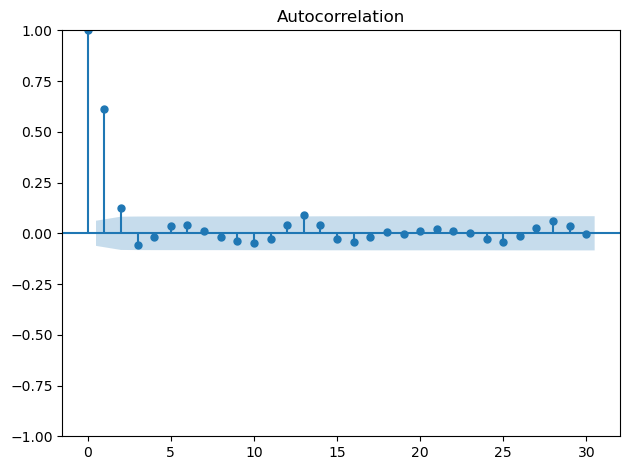

In [34]:
plot_acf(process, lags = 30)

plt.tight_layout()

plt.show()

In [35]:
# 훈련/테스트 분할
df = pd.DataFrame({"value" : process})

train = df[:800]
test = df[800:]

In [36]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2
Q = 2

In [37]:
# 롤링 예측
pred_mean = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "mean", Q)
pred_last_value = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "last", Q)
pred_ma = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "MA", Q)

In [38]:
test["pred_mean"] = pred_mean
test["pred_last_value"] = pred_last_value
test["pred_MA"] = pred_ma

test.head()

,value,pred_mean,pred_last_value,pred_MA
800,1.432558,-0.133197,1.508639,0.814949
801,1.545564,-0.133197,1.508639,0.185429
802,1.126026,-0.129152,1.545564,0.941731
803,-1.870220,-0.129152,1.545564,0.276360
804,-3.242207,-0.129756,-1.870220,-2.052637


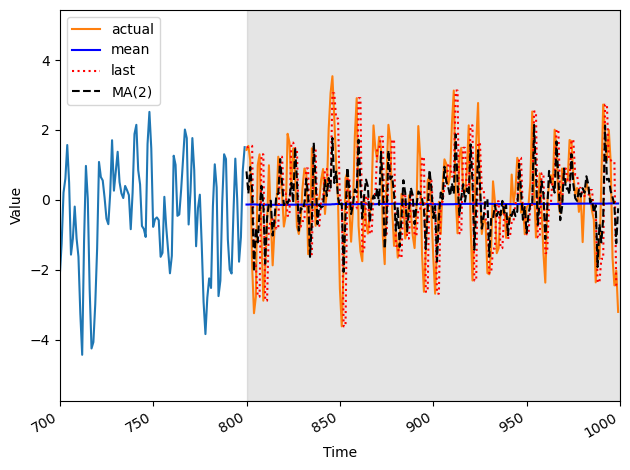

In [39]:
fig, ax = plt.subplots()

ax.plot(train)
ax.plot(test["value"], label = "actual")
ax.plot(test["pred_mean"], "b-", label = "mean")
ax.plot(test["pred_last_value"], "r:", label = "last")
ax.plot(test["pred_MA"], "k--", label = "MA(2)")

ax.legend()

ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.axvspan(800, 1000, color = "#808080", alpha = 0.2)

ax.set_xlim(700, 1000)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [40]:
# 모델 성능 측정(mse)
mse_mean = mean_squared_error(test["value"], test["pred_mean"])
mse_last = mean_squared_error(test["value"], test["pred_last_value"])
mse_MA = mean_squared_error(test["value"], test["pred_MA"])

print(mse_mean, mse_last, mse_MA)

1.8795227685845122 2.9216523054724295 1.5241105170685665


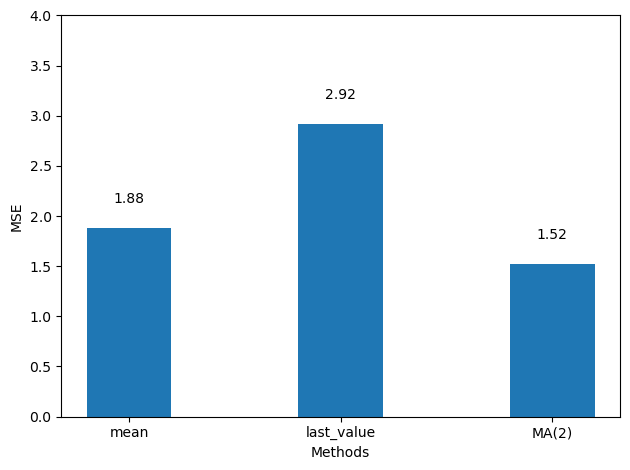

In [41]:
fig, ax = plt.subplots()

x = ["mean", "last_value", "MA(2)"]
y = [mse_mean, mse_last, mse_MA]

ax.bar(x, y, width = 0.4)

ax.set_xlabel("Methods")
ax.set_ylabel("MSE")
ax.set_ylim(0, 4)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.25, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

## 예측수행하기_2

In [42]:
process = np.load("./data/npy/q4-2.npy")

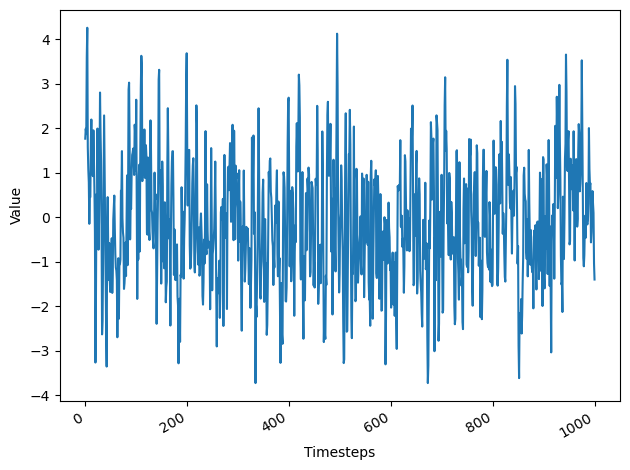

In [43]:
fig, ax = plt.subplots()

ax.plot(process)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [44]:
# 정상성 테스트
ADF_result = adfuller(process)

print(f"ADF Statistic: {ADF_result[0]}") # ADF 통계 출력
print(f"p-value: {ADF_result[1]}") # p-value 출력

ADF Statistic: -7.051456339798381
p-value: 5.51279479473998e-10


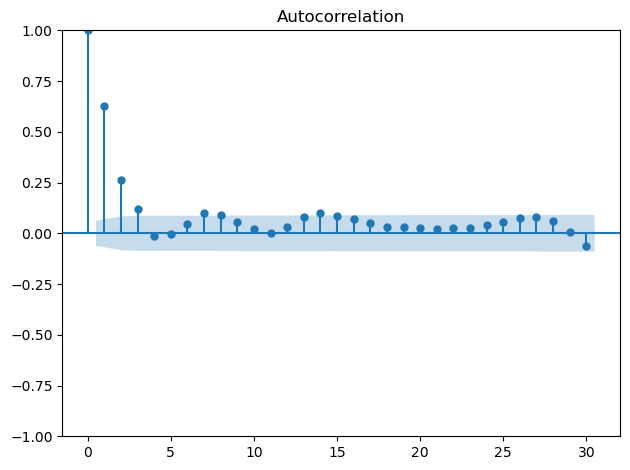

In [45]:
plot_acf(process, lags = 30)

plt.tight_layout()

plt.show()

In [46]:
process.shape

(1000,)

In [47]:
df = pd.DataFrame({"value" : process})

train = df[:800]
test = df[800:]

test.shape

(200, 1)

In [48]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 3
Q = 3

In [49]:
pred_mean = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "mean", Q)
pred_last_value = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "last", Q)
pred_ma = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "MA", Q)

In [50]:
test["pred_mean"] = pred_mean[:200]
test["pred_last_value"] = pred_last_value[:200]
test["pred_MA"] = pred_ma[:200]

test.head()

,value,pred_mean,pred_last_value,pred_MA
800,0.321385,-0.174488,-1.520374,-1.099606
801,1.721937,-0.174488,-1.520374,-0.375293
802,0.907113,-0.174488,-1.520374,-0.207720
803,0.075036,-0.170162,0.907113,0.568480
804,0.728742,-0.170162,0.907113,0.195433


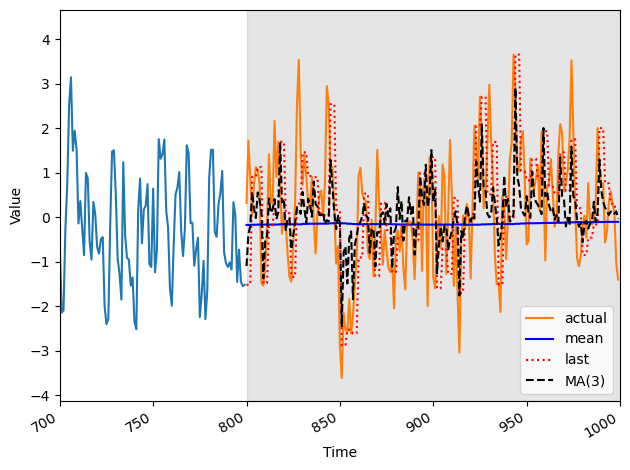

In [51]:
fig, ax = plt.subplots()

ax.plot(train)
ax.plot(test["value"], label = "actual")
ax.plot(test["pred_mean"], "b-", label = "mean")
ax.plot(test["pred_last_value"], "r:", label = "last")
ax.plot(test["pred_MA"], "k--", label = "MA(3)")

ax.legend()

ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.axvspan(800, 1000, color = "#808080", alpha = 0.2)

ax.set_xlim(700, 1000)

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [52]:
mse_mean = mean_squared_error(test["value"], test["pred_mean"])
mse_last = mean_squared_error(test["value"], test["pred_last_value"])
mse_MA = mean_squared_error(test["value"], test["pred_MA"])

print(mse_mean, mse_last, mse_MA)

1.763225144791902 1.8073362705675533 1.277894899115903


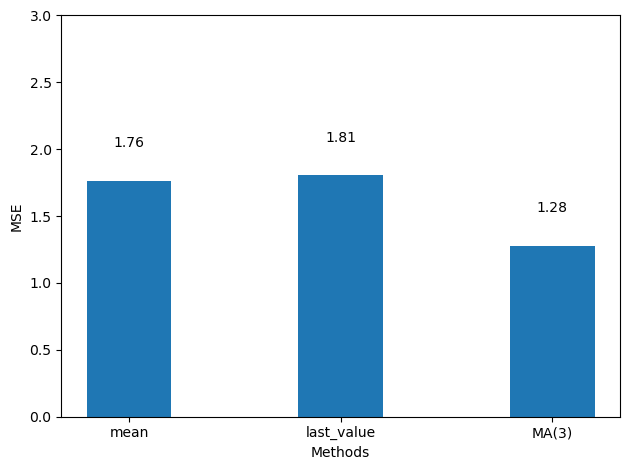

In [53]:
fig, ax = plt.subplots()

x = ["mean", "last_value", "MA(3)"]
y = [mse_mean, mse_last, mse_MA]

ax.bar(x, y, width = 0.4)

ax.set_xlabel("Methods")
ax.set_ylabel("MSE")
ax.set_ylim(0, 3)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.25, s = str(round(value, 2)), ha = "center")

plt.tight_layout()
plt.show()

# 정리

- 이동평균프로세스는 현재의 값이 평균과 현재 오차 항, 과거 오차 항에 선형적으로 의존함

- ACF 그래프를 통해 정상적 이동평균프로세스의 차수 q를 식별할 수 있음. 계수는 지연 q까지만 유의함

- 오차 항은 데이터에서 관찰되지 않고 재귀적으로 추정해야 하기 때문에 최대 q 단계의 미래까지 예측할 수 있음

- 데이터에 변환을 적용한 경우 예측을 원본 데이터의 단위로 되돌리기 위해 역변환을 수행해야 함

- 이동평균 모델은 데이터가 정상적이라고 가정함. 따라서 이 모델은 정상적 데이터에만 사용할 수 있음